# A/B-тестирование рекламной кампании

## Цель

Проверить, увеличивает ли рекламная кампания конверсию пользователей по сравнению с контрольной группой PSA.

Датасет: https://www.kaggle.com/datasets/faviovaz/marketing-ab-testing/data

Группы:

- `ad` — пользователь видел рекламу;
- `psa` — пользователь видел public service announcement, контрольный вариант.

## Статистическая гипотеза

Обозначения:

- `CR_ad` — конверсия пользователей, которые видели рекламу;
- `CR_psa` — конверсия контрольной группы.

Гипотезы:

- **H0:** `CR_ad ≤ CR_psa`, рекламная кампания не увеличивает конверсию;
- **H1:** `CR_ad > CR_psa`, рекламная кампания увеличивает конверсию.

Тестовая статистика рассчитывается при граничном случае H0: `CR_ad = CR_psa`.

## Параметры эксперимента

- **Статистический метод:** one-sided two-sample z-test for proportions
- **MDE:** 0.5 percentage points
- **Уровень значимости:** α = 0.05

## План анализа

1. Загрузить данные.
2. Проверить структуру данных, пропуски и дубликаты.
3. Проверить размеры групп.
4. Посчитать conversion rate.
5. Посчитать absolute и relative uplift.
6. Провести one-sided z-test для сравнения долей.
7. Построить 95% доверительный интервал для разницы конверсий.
8. Проверить достижение MDE.
9. Провести chi-square test как дополнительную проверку.
10. Провести анализ по дням недели, часам и количеству показов.
11. Сформулировать вывод.

In [79]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats
from scipy.stats import norm

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.4f}".format)

ALPHA = 0.05
MDE = 0.005  # 0.5 percentage points

## 1. Загрузка данных

In [80]:
local_path = Path("data/marketing_AB.csv")

github_url = "https://raw.githubusercontent.com/daze7/Marketing-A-B-Testing/main/marketing_AB.csv"

if local_path.exists():
    df = pd.read_csv(local_path)
else:
    df = pd.read_csv(github_url)

df.head()

,Unnamed: 0,user id,test group,converted,total ads,most ads day,most ads hour
0,0,1069124,ad,False,130,Monday,20
1,1,1119715,ad,False,93,Tuesday,22
2,2,1144181,ad,False,21,Tuesday,18
3,3,1435133,ad,False,355,Tuesday,10
4,4,1015700,ad,False,276,Friday,14


In [81]:
# Приводим названия колонок к удобному виду
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

# Удаляем служебный индекс
for col in ["unnamed:_0", "index"]:
    if col in df.columns:
        df = df.drop(columns=[col])

df.head()

,user_id,test_group,converted,total_ads,most_ads_day,most_ads_hour
0,1069124,ad,False,130,Monday,20
1,1119715,ad,False,93,Tuesday,22
2,1144181,ad,False,21,Tuesday,18
3,1435133,ad,False,355,Tuesday,10
4,1015700,ad,False,276,Friday,14


In [82]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 588101 entries, 0 to 588100
Data columns (total 6 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   user_id        588101 non-null  int64 
 1   test_group     588101 non-null  object
 2   converted      588101 non-null  bool  
 3   total_ads      588101 non-null  int64 
 4   most_ads_day   588101 non-null  object
 5   most_ads_hour  588101 non-null  int64 
dtypes: bool(1), int64(3), object(2)
memory usage: 23.0+ MB


## Словарь данных

- **user_id** — идентификатор пользователя;
- **test_group** — группа эксперимента: `ad` или `psa`;
- **converted** — факт конверсии: `True` / `False`;
- **total_ads** — количество объявлений, просмотренных пользователем;
- **most_ads_day** — день, когда пользователь увидел наибольшее количество объявлений;
- **most_ads_hour** — час, когда пользователь увидел наибольшее количество объявлений.

## 2. Проверка качества данных

Перед расчётом метрик проверим пропуски, дубликаты пользователей и допустимые значения ключевых колонок.

In [83]:
df.isna().sum()

,0
user_id,0
test_group,0
converted,0
total_ads,0
most_ads_day,0
most_ads_hour,0


In [84]:
df["user_id"].duplicated().sum()

np.int64(0)

In [85]:
df["test_group"].value_counts()

,count
test_group,
ad,564577
psa,23524


In [86]:
df["converted"].value_counts()

,count
converted,
False,573258
True,14843


## 3. Проверка групп

Смотрим абсолютное и относительное распределение пользователей между группами.

In [87]:
df["test_group"].value_counts()

,count
test_group,
ad,564577
psa,23524


In [88]:
df["test_group"].value_counts(normalize=True)

,proportion
test_group,
ad,0.9600
psa,0.0400


### Комментарий по размеру групп

Группы сильно несбалансированы: большая часть пользователей находится в группе `ad`, а меньшая часть — в группе `psa`.

Статистический тест для долей учитывает разные размеры выборок, поэтому анализ можно проводить. Однако меньший размер контрольной группы увеличивает неопределённость оценки для `psa`, особенно в сегментном анализе.

## 4. Основные метрики

Целевая метрика — conversion rate.

In [89]:
summary = df.groupby("test_group").agg(
    users=("user_id", "nunique"),
    conversions=("converted", "sum"),
    conversion_rate=("converted", "mean"),
    avg_ads=("total_ads", "mean"),
    median_ads=("total_ads", "median"),
).sort_index()

summary

,users,conversions,conversion_rate,avg_ads,median_ads
test_group,,,,,
ad,564577,14423,0.0255,24.8234,13.0000
psa,23524,420,0.0179,24.7611,12.0000


In [90]:
cr_ad = summary.loc["ad", "conversion_rate"]
cr_psa = summary.loc["psa", "conversion_rate"]

absolute_uplift = cr_ad - cr_psa
relative_uplift = absolute_uplift / cr_psa

print(f"Conversion ad:     {cr_ad:.4%}")
print(f"Conversion psa:    {cr_psa:.4%}")
print(f"Absolute uplift:   {absolute_uplift:.4%}")
print(f"Relative uplift:   {relative_uplift:.2%}")
print(f"MDE:               {MDE:.2%}")
print(f"Alpha:             {ALPHA}")

Conversion ad:     2.5547%
Conversion psa:    1.7854%
Absolute uplift:   0.7692%
Relative uplift:   43.09%
MDE:               0.50%
Alpha:             0.05


## 5. Визуализация конверсии

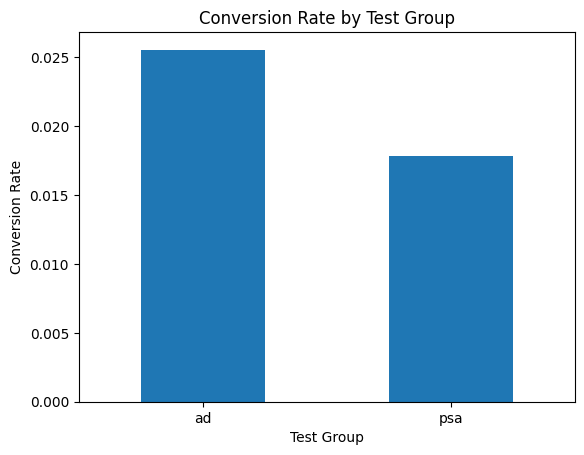

In [91]:
summary["conversion_rate"].plot(kind="bar")
plt.title("Conversion Rate by Test Group")
plt.xlabel("Test Group")
plt.ylabel("Conversion Rate")
plt.xticks(rotation=0)
plt.show()

## 6. Односторонний z-test для сравнения конверсий

Используем **one-sided two-sample z-test for proportions**.

Проверяем:

- **H0:** `CR_ad ≤ CR_psa`
- **H1:** `CR_ad > CR_psa`

Тестовая статистика рассчитывается при граничном случае H0: `CR_ad = CR_psa`.


In [92]:
x_ad = int(summary.loc["ad", "conversions"])
n_ad = int(summary.loc["ad", "users"])

x_psa = int(summary.loc["psa", "conversions"])
n_psa = int(summary.loc["psa", "users"])

p_ad = x_ad / n_ad
p_psa = x_psa / n_psa

# Pooled proportion under H0: CR_ad = CR_psa
p_pool = (x_ad + x_psa) / (n_ad + n_psa)

se_pool = np.sqrt(
    p_pool * (1 - p_pool) * (1 / n_ad + 1 / n_psa)
)

z_stat = (p_ad - p_psa) / se_pool

# One-sided p-value for H1: CR_ad > CR_psa
p_value = 1 - norm.cdf(z_stat)

print(f"z-statistic: {z_stat:.4f}")
print(f"p-value:     {p_value:.2e}")

z-statistic: 7.3701
p-value:     8.53e-14


In [93]:
if p_value < ALPHA:
    print("p-value < 0.05: отвергаем H0. Есть статистически значимый рост конверсии в ad.")
else:
    print("p-value >= 0.05: недостаточно оснований утверждать, что ad увеличивает конверсию.")

p-value < 0.05: отвергаем H0. Есть статистически значимый рост конверсии в ad.


## 7. 95% доверительный интервал для разницы конверсий

Считаем интервал для разницы:

```text
CR_ad - CR_psa
```

p-value показывает, есть ли статистически значимый эффект.  
Доверительный интервал показывает, какого размера может быть настоящий эффект.

In [94]:
se = np.sqrt(
    p_ad * (1 - p_ad) / n_ad +
    p_psa * (1 - p_psa) / n_psa
)

diff = p_ad - p_psa
z_crit = norm.ppf(0.975)

ci_low = diff - z_crit * se
ci_high = diff + z_crit * se

print(f"Difference CR_ad - CR_psa: {diff:.4%}")
print(f"95% CI: [{ci_low:.4%}; {ci_high:.4%}]")

Difference CR_ad - CR_psa: 0.7692%
95% CI: [0.5951%; 0.9434%]


## 8. Проверка MDE

MDE = 0.5 процентного пункта.  
Это минимальный эффект, который считаем продуктово значимым.

Для более строгого вывода проверяем не только точечную оценку `absolute_uplift`, но и нижнюю границу доверительного интервала `ci_low`.

In [95]:
if ci_low >= MDE:
    print("ci_low >= MDE: даже нижняя граница 95% CI выше MDE. Эффект можно считать продуктово значимым.")
elif absolute_uplift >= MDE:
    print("Observed uplift >= MDE, но нижняя граница 95% CI ниже MDE. Нужна осторожная интерпретация.")
else:
    print("Observed uplift < MDE: эффект может быть слишком маленьким для продуктового решения.")

ci_low >= MDE: даже нижняя граница 95% CI выше MDE. Эффект можно считать продуктово значимым.


## 9. χ²-тест

Дополнительно проверим связь между группой эксперимента и фактом конверсии через таблицу сопряжённости.

Гипотезы:

- **H0:** `test_group` и `converted` независимы;
- **H1:** между `test_group` и `converted` есть статистически значимая связь.

Этот тест используется как дополнительная проверка.

In [96]:
contingency = pd.crosstab(df["test_group"], df["converted"])
contingency

converted,False,True
test_group,,
ad,550154,14423
psa,23104,420


In [97]:
chi2, p_chi2, dof, expected = stats.chi2_contingency(contingency)

print(f"chi2: {chi2:.4f}")
print(f"p-value: {p_chi2:.2e}")
print(f"degrees of freedom: {dof}")

chi2: 54.0058
p-value: 2.00e-13
degrees of freedom: 1


## 10. Сегментный анализ по дням недели

Смотрим, сохраняется ли преимущество группы `ad` в разных днях недели.

In [98]:
by_day = df.groupby(["most_ads_day", "test_group"]).agg(
    users=("user_id", "nunique"),
    conversion_rate=("converted", "mean"),
    avg_ads=("total_ads", "mean")
).reset_index()

by_day

,most_ads_day,test_group,users,conversion_rate,avg_ads
0,Friday,ad,88805,0.0225,26.6826
1,Friday,psa,3803,0.0163,24.9671
2,Monday,ad,83571,0.0332,25.3898
3,Monday,psa,3502,0.0226,23.8669
4,Saturday,ad,78802,0.0213,25.1268
5,Saturday,psa,2858,0.0140,28.0084
6,Sunday,ad,82332,0.0246,24.3691
7,Sunday,psa,3059,0.0206,25.3328
8,Thursday,ad,79077,0.0216,23.2676
9,Thursday,psa,3905,0.0202,26.6940


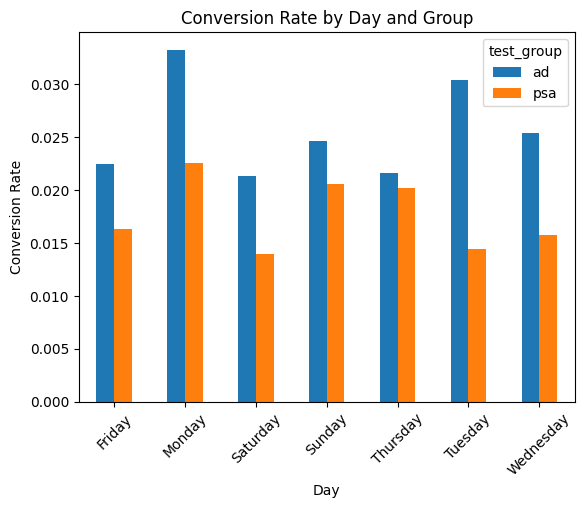

In [99]:
pivot_day = by_day.pivot(
    index="most_ads_day",
    columns="test_group",
    values="conversion_rate"
)

pivot_day.plot(kind="bar")
plt.title("Conversion Rate by Day and Group")
plt.xlabel("Day")
plt.ylabel("Conversion Rate")
plt.xticks(rotation=45)
plt.show()

## 11. Сегментный анализ по часам

Почасовой анализ следует интерпретировать осторожно: контрольная группа `psa` значительно меньше, поэтому оценки конверсии в отдельных часах могут быть нестабильными.

In [100]:
by_hour = df.groupby(["most_ads_hour", "test_group"]).agg(
    users=("user_id", "nunique"),
    conversion_rate=("converted", "mean")
).reset_index()

by_hour.head()

,most_ads_hour,test_group,users,conversion_rate
0,0,ad,5309,0.0192
1,0,psa,227,0.0000
2,1,ad,4615,0.0134
3,1,psa,187,0.0000
4,2,ad,5152,0.0076


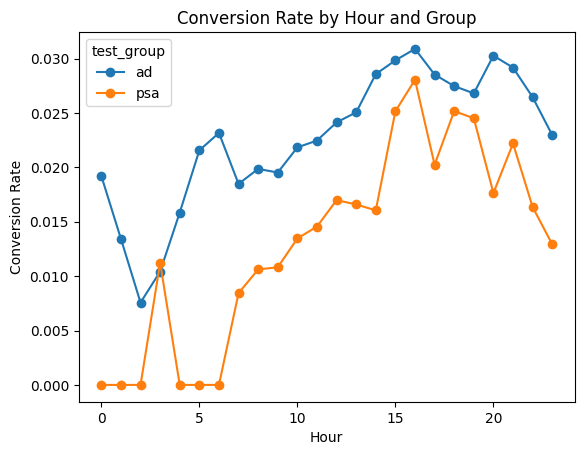

In [101]:
pivot_hour = by_hour.pivot(
    index="most_ads_hour",
    columns="test_group",
    values="conversion_rate"
)

pivot_hour.plot(kind="line", marker="o")
plt.title("Conversion Rate by Hour and Group")
plt.xlabel("Hour")
plt.ylabel("Conversion Rate")
plt.show()

## 12. Сегментный анализ по количеству показов


In [102]:
df["ads_bucket"] = pd.cut(
    df["total_ads"],
    bins=[0, 5, 10, 20, 50, df["total_ads"].max()],
    labels=["1-5", "6-10", "11-20", "21-50", "51+"],
    include_lowest=True
)

by_ads = df.groupby(["ads_bucket", "test_group"], observed=True).agg(
    users=("user_id", "nunique"),
    conversion_rate=("converted", "mean")
).reset_index()

by_ads

,ads_bucket,test_group,users,conversion_rate
0,1-5,ad,169962,0.0025
1,1-5,psa,7861,0.0028
2,6-10,ad,79537,0.0049
3,6-10,psa,3415,0.0067
4,11-20,ad,123334,0.0084
5,11-20,psa,4150,0.0082
6,21-50,ad,125541,0.0292
7,21-50,psa,5235,0.0218
8,51+,ad,66203,0.1346
9,51+,psa,2863,0.0793


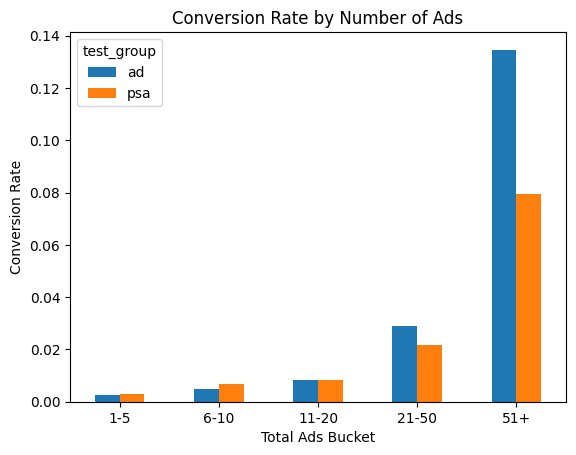

In [103]:
pivot_ads = by_ads.pivot(
    index="ads_bucket",
    columns="test_group",
    values="conversion_rate"
)

pivot_ads.plot(kind="bar")
plt.title("Conversion Rate by Number of Ads")
plt.xlabel("Total Ads Bucket")
plt.ylabel("Conversion Rate")
plt.xticks(rotation=0)
plt.show()

## 13. Ограничения анализа

1. Группы сильно несбалансированы: около 96% пользователей находятся в группе `ad`, около 4% — в `psa`.
2. В датасете нет информации о стоимости рекламы, маржинальности и выручке, поэтому нельзя окончательно оценить экономическую эффективность кампании.


## 14. Итоговый вывод

In [104]:
print(f"Conversion ad:    {cr_ad:.4%}")
print(f"Conversion psa:   {cr_psa:.4%}")
print(f"Absolute uplift:  {absolute_uplift:.4%}")
print(f"Relative uplift:  {relative_uplift:.2%}")
print(f"MDE:              {MDE:.2%}")
print(f"p-value:          {p_value:.2e}")
print(f"95% CI:           [{ci_low:.4%}; {ci_high:.4%}]")

if p_value < ALPHA and ci_low >= MDE:
    print(
        "\nФинальный вывод: рекламная кампания статистически значимо увеличивает конверсию, "
        "и даже нижняя граница 95% доверительного интервала выше MDE. "
        "Эффект можно считать не только статистически, но и продуктово значимым. "
        "Кампанию можно рекомендовать к масштабированию при условии, что дополнительная выручка покрывает стоимость рекламы."
    )
elif p_value < ALPHA and absolute_uplift >= MDE:
    print(
        "\nФинальный вывод: рост конверсии статистически значим, observed uplift выше MDE, "
        "но доверительный интервал не полностью выше MDE. Нужно дополнительно оценить экономику и риски."
    )
elif p_value < ALPHA:
    print(
        "\nФинальный вывод: рост конверсии статистически значим, но эффект меньше MDE. "
        "С продуктовой точки зрения масштабирование может быть неоправданным."
    )
else:
    print(
        "\nФинальный вывод: недостаточно оснований утверждать, что реклама увеличивает конверсию."
    )

Conversion ad:    2.5547%
Conversion psa:   1.7854%
Absolute uplift:  0.7692%
Relative uplift:  43.09%
MDE:              0.50%
p-value:          8.53e-14
95% CI:           [0.5951%; 0.9434%]

Финальный вывод: рекламная кампания статистически значимо увеличивает конверсию, и даже нижняя граница 95% доверительного интервала выше MDE. Эффект можно считать не только статистически, но и продуктово значимым. Кампанию можно рекомендовать к масштабированию при условии, что дополнительная выручка покрывает стоимость рекламы.


### Текстовый итог

В ходе анализа была проверена гипотеза о том, что рекламная кампания увеличивает конверсию пользователей по сравнению с контрольной группой `psa`.

Конверсия в группе `ad` выше, чем в группе `psa`. Односторонний z-test для двух пропорций показывает статистически значимый рост конверсии в группе `ad`. 95% доверительный интервал для разницы конверсий полностью находится выше нуля.

При заданном MDE = 0.5 п.п. эффект можно считать не только статистически значимым, но и продуктово значимым, если нижняя граница доверительного интервала превышает MDE.

Дополнительный χ²-тест подтверждает статистически значимую связь между группой эксперимента и фактом конверсии.

Итог: рекламная кампания статистически значимо повышает конверсию и достигает заданного порога продуктовой значимости. Кампанию можно рекомендовать к масштабированию при условии, что дополнительная выручка покрывает стоимость рекламы.